# 01 - AMM simulator and parameter analysis

Synthetic CPMM experiments. This notebook answers the core simulator question: for which pool/victim/cost/fee/slippage parameters is a sandwich attack both profitable and executable?

Inputs:
- `results/sweep.csv`
- optional `results/zhou_vs_numerical.csv`


## Load data


In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "helpers").exists():
        sys.path.insert(0, str(candidate))
        break
    if (candidate / "notebooks" / "helpers").exists():
        sys.path.insert(0, str(candidate / "notebooks"))
        break

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from helpers import (
    best_conditions,
    blocker_table,
    data_readiness,
    find_repo_root,
    historical_counterfactual_summary,
    hypothesis_scorecard,
    load_inputs,
    plot_realized_heatmap,
    plot_sensitivity_lines,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

ROOT = find_repo_root()
inputs = load_inputs(ROOT)

sweep = inputs["frames"]["synthetic_sweep"]
zhou = inputs["frames"]["zhou_vs_numerical"]

display(data_readiness(ROOT, inputs, ["synthetic_sweep", "zhou_vs_numerical"]))
if sweep.attrs.get("legacy_schema", False):
    display(Markdown("> `sweep.csv` uses an old schema. Regenerate it before using final thesis numbers."))


,dataset,file,rows,columns,ready_for_final_numbers,note
0,synthetic_sweep,results/sweep.csv,1344,36,True,ok
1,zhou_vs_numerical,results/zhou_vs_numerical.csv,672,25,True,ok


## Research scorecard


In [2]:
if sweep.empty:
    display(Markdown("Generate `results/sweep.csv` first."))
else:
    display(hypothesis_scorecard(sweep))
    display(Markdown("### Main blockers"))
    display(blocker_table(sweep))
    display(Markdown("### Highest-profit realized parameter rows"))
    display(best_conditions(sweep))


,question,metric,value
0,Czy atak zarabia przed slippage filter?,profitable rows,8.9%
1,Czy ofiara nie revertuje?,feasible rows,60.7%
2,Czy atak jest ekonomicznie realizowalny?,profitable and feasible rows,0.0%
3,Typowy wynik attackera,median net profit,"-331,444"
4,Typowa strata ofiary w udanych przypadkach,median victim loss bps,n/a


### Main blockers

,blocker,rows,share,median_net_profit,median_victim_loss_bps
0,not_profitable,1224,0.910714,-331493.5,49.0
1,victim_would_revert,120,0.089286,250501.5,6153.5


### Highest-profit realized parameter rows

""


## Parameter surface


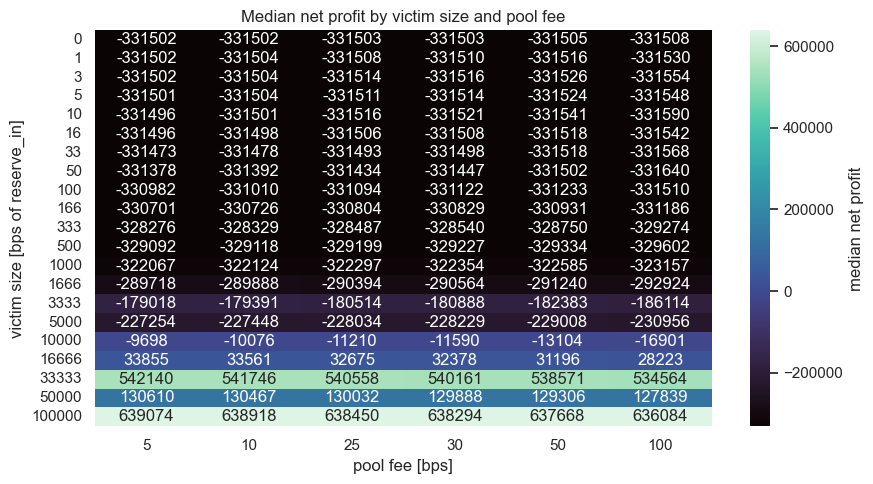

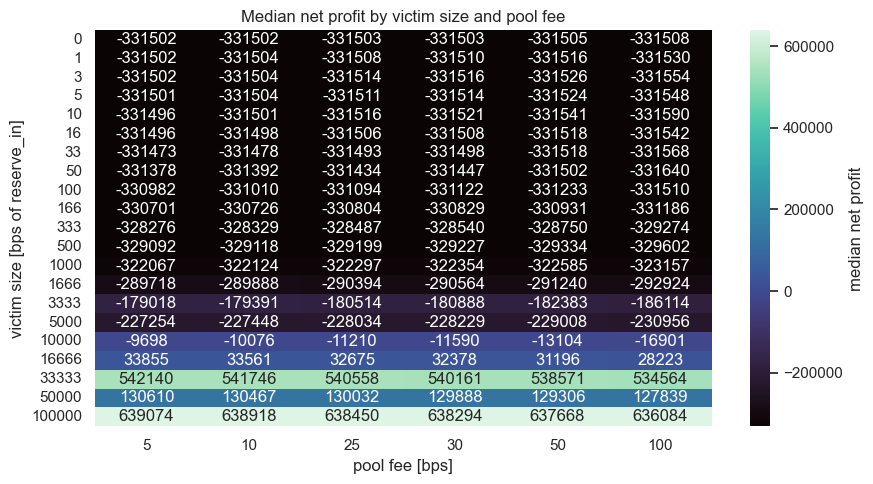

In [3]:
plot_realized_heatmap(
    sweep,
    value="attack_realized",
    title="Attack success rate: profitable and feasible",
    cbar_label="success rate",
)
plot_realized_heatmap(
    sweep,
    value="attacker_net_profit",
    title="Median net profit by victim size and pool fee",
    cbar_label="median net profit",
    fmt=".0f",
    cmap="mako",
)


## Profitability, feasibility and blockers


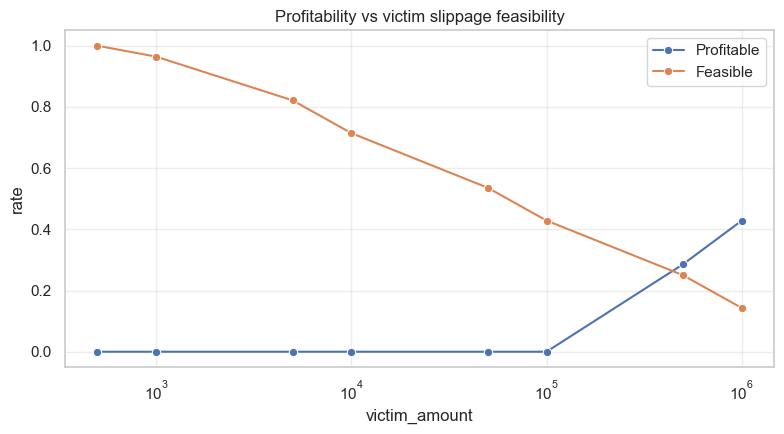

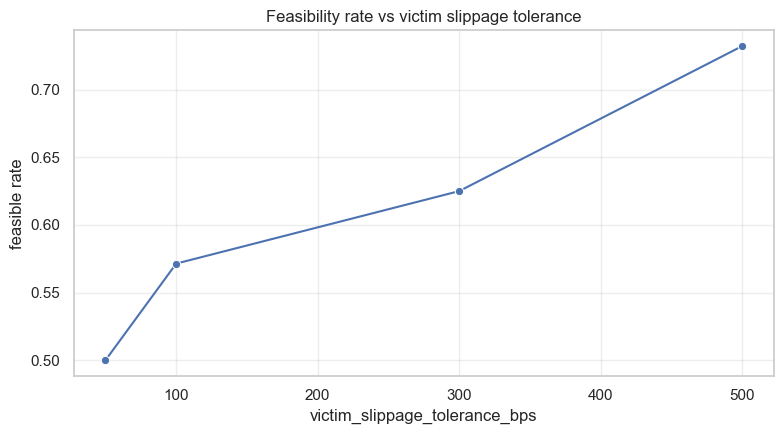

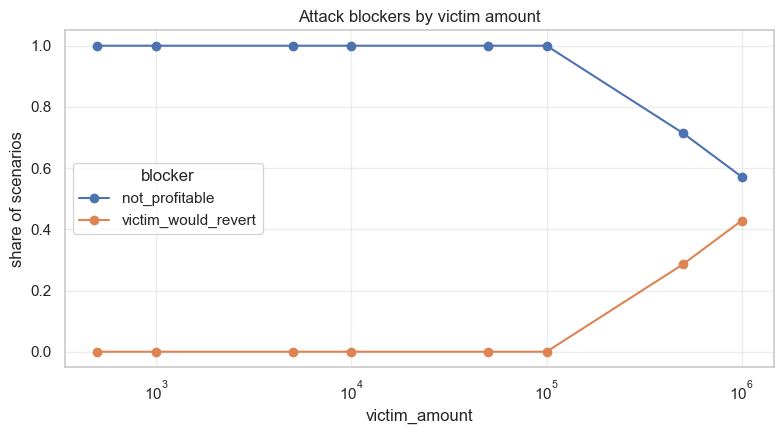

In [4]:
if sweep.empty:
    display(Markdown("No sweep data."))
else:
    by_victim = (
        sweep.groupby("victim_amount")
        .agg(
            profitable_rate=("attack_profitable", "mean"),
            feasible_rate=("attack_feasible", "mean"),
        )
        .reset_index()
        .sort_values("victim_amount")
    )
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.lineplot(data=by_victim, x="victim_amount", y="profitable_rate", marker="o", label="Profitable", ax=ax)
    sns.lineplot(data=by_victim, x="victim_amount", y="feasible_rate", marker="o", label="Feasible", ax=ax)
    ax.set_xscale("log")
    ax.set_title("Profitability vs victim slippage feasibility")
    ax.set_xlabel("victim_amount")
    ax.set_ylabel("rate")
    ax.grid(True, alpha=0.35)
    plt.tight_layout()

    by_slippage = (
        sweep.groupby("victim_slippage_tolerance_bps")
        .agg(feasible_rate=("attack_feasible", "mean"))
        .reset_index()
        .sort_values("victim_slippage_tolerance_bps")
    )
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.lineplot(data=by_slippage, x="victim_slippage_tolerance_bps", y="feasible_rate", marker="o", ax=ax)
    ax.set_title("Feasibility rate vs victim slippage tolerance")
    ax.set_xlabel("victim_slippage_tolerance_bps")
    ax.set_ylabel("feasible rate")
    ax.grid(True, alpha=0.35)
    plt.tight_layout()

    blockers = (
        sweep.groupby(["victim_amount", "blocker"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )
    blockers = blockers.div(blockers.sum(axis=1), axis=0)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    blockers.plot(marker="o", ax=ax)
    ax.set_xscale("log")
    ax.set_title("Attack blockers by victim amount")
    ax.set_xlabel("victim_amount")
    ax.set_ylabel("share of scenarios")
    ax.grid(True, alpha=0.35)
    plt.tight_layout()


## Strategy comparison


In [5]:
if sweep.empty:
    display(Markdown("No sweep data."))
else:
    display(
        sweep.groupby(["strategy", "pool_fee_bps"], dropna=False)
        .agg(
            rows=("strategy", "size"),
            realized_rate=("attack_realized", "mean"),
            profitable_rate=("attack_profitable", "mean"),
            median_net_profit=("attacker_net_profit", "median"),
            median_frontrun_bps=("frontrun_size_bps_of_reserve", "median"),
        )
        .reset_index()
        .sort_values(["strategy", "pool_fee_bps"])
    )


,strategy,pool_fee_bps,rows,realized_rate,profitable_rate,median_net_profit,median_frontrun_bps
0,closed_form,5,224,0.0,0.089286,-331342.0,36.5
1,closed_form,10,224,0.0,0.089286,-331356.5,36.5
2,closed_form,25,224,0.0,0.089286,-331423.0,36.5
3,closed_form,30,224,0.0,0.089286,-331433.0,36.5
4,closed_form,50,224,0.0,0.089286,-331498.5,36.5
5,closed_form,100,224,0.0,0.089286,-331505.5,36.5


## Closed-form baseline vs numerical optimizer


,liquidity_depth_label,fee_bps,rows,median_profit_gap,p90_profit_gap,median_frontrun_gap,median_grid_gap
0,deep,0,24,127890.5,661170.0,9912475.5,-2.0
1,deep,5,24,122914.5,656374.0,9840064.0,-1.0
2,deep,10,24,117936.0,651573.0,9814283.0,0.0
3,deep,30,24,97995.5,632345.0,9632349.5,0.0
4,deep,50,24,78013.0,613067.0,9592587.0,-0.5
5,deep,100,24,42089.0,564665.0,4753387.5,0.0
6,deep,250,24,1978.5,417639.0,-14983.5,0.0
7,medium,0,24,12787.5,66116.0,987327.0,-1.0
8,medium,5,24,12291.0,65637.0,981210.5,0.0
9,medium,10,24,11793.0,65156.0,981248.5,0.0


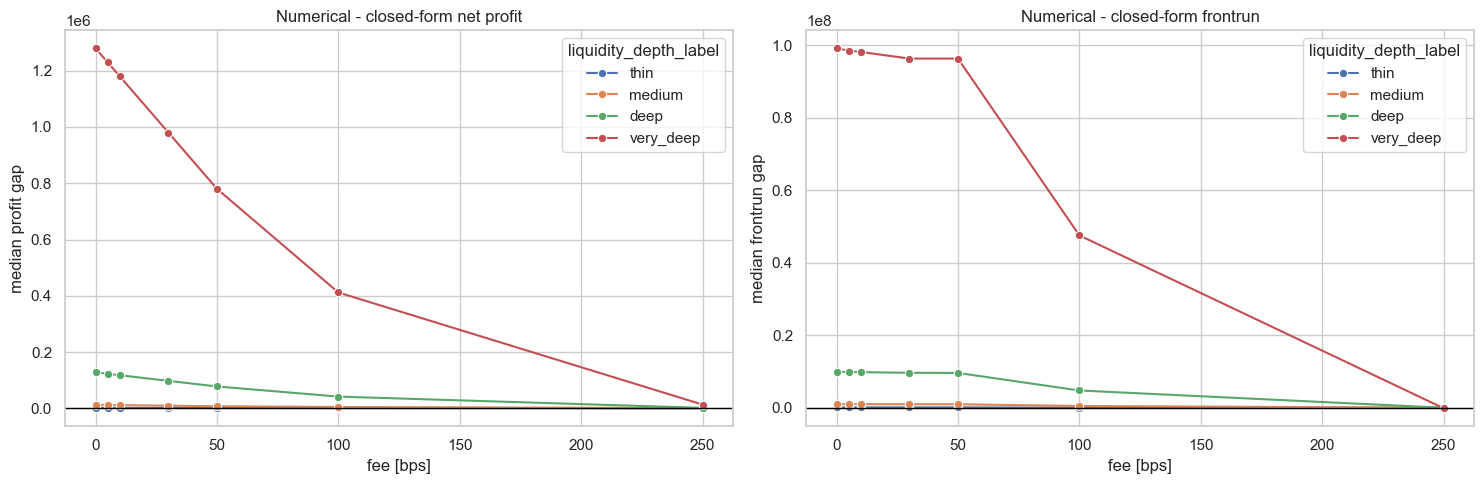

In [6]:
if zhou.empty:
    display(Markdown("Generate `results/zhou_vs_numerical.csv` to validate the optimizer choice."))
else:
    display(
        zhou.groupby(["liquidity_depth_label", "fee_bps"])
        .agg(
            rows=("fee_bps", "size"),
            median_profit_gap=("profit_gap_abs", "median"),
            p90_profit_gap=("profit_gap_abs", lambda s: s.quantile(0.9)),
            median_frontrun_gap=("frontrun_gap_abs", "median"),
            median_grid_gap=("numerical_grid_profit_gap", "median"),
        )
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.lineplot(data=zhou, x="fee_bps", y="profit_gap_abs", hue="liquidity_depth_label", estimator="median", errorbar=None, marker="o", ax=axes[0])
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title("Numerical - closed-form net profit")
    axes[0].set_xlabel("fee [bps]")
    axes[0].set_ylabel("median profit gap")

    sns.lineplot(data=zhou, x="fee_bps", y="frontrun_gap_abs", hue="liquidity_depth_label", estimator="median", errorbar=None, marker="o", ax=axes[1])
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_title("Numerical - closed-form frontrun")
    axes[1].set_xlabel("fee [bps]")
    axes[1].set_ylabel("median frontrun gap")
    plt.tight_layout()


## Thesis-ready takeaways


In [7]:
if sweep.empty:
    display(Markdown("No conclusions yet."))
else:
    by_size = sweep.groupby("victim_size_bps_of_reserve")["attack_realized"].mean().sort_index()
    by_cost = sweep.groupby("tx_cost_per_leg")["attack_realized"].mean().sort_index()
    lines = [
        f"- Synthetic sweep rows: `{len(sweep)}`.",
        f"- Profitable and feasible rate: `{sweep['attack_realized'].mean():.1%}`.",
        f"- Victim-size sensitivity: `{by_size.iloc[0]:.1%}` at `{by_size.index[0]:.0f}` bps vs `{by_size.iloc[-1]:.1%}` at `{by_size.index[-1]:.0f}` bps.",
        f"- Cost sensitivity: `{by_cost.iloc[0]:.1%}` at lowest modeled per-leg cost vs `{by_cost.iloc[-1]:.1%}` at highest modeled per-leg cost.",
    ]
    display(Markdown("\n".join(lines)))


- Synthetic sweep rows: `1344`.
- Profitable and feasible rate: `0.0%`.
- Victim-size sensitivity: `0.0%` at `0` bps vs `0.0%` at `100000` bps.
- Cost sensitivity: `0.0%` at lowest modeled per-leg cost vs `0.0%` at highest modeled per-leg cost.